I will compare a joint auto-encoder generator vs a pretrained auto-encoder generator on a high dimensional toy example


I will first verify I can drift while training the encoder while avoiding latent collapse


Then I will see using X metric if there is any advantage in training the generator and auto-encoder at the same time

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch._utils
import time
import torch.nn.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
print(torch.__version__)

2.11.0+cu128


In [4]:
# define the model architecture for the generator, encoder and decoder
class f(nn.Module):
    def __init__(self, latent_dim=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = 128

        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 64),
            nn.LeakyReLU(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            
            # nn.Linear(512, latent_dim)
        )

        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_var = nn.Linear(16, latent_dim)

        # self.decoder_input = nn.Linear(latent_dim, 1024)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, self.input_dim) # Agrega nn.Sigmoid() al final si tus datos están normalizados entre 0 y 1
        )
        
        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, self.latent_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def get_latent(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent
    
    def generate(self, noise):
        _, _, latent = self.get_latent(noise)
        generated_latent = self.generator(latent)
        generated_final = self.decoder(generated_latent)
        return generated_latent, generated_final

In [5]:
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_neg, y_pos, T, eps=1e-8):
    N = y_neg.shape[0]
    points = torch.cat([y_neg, y_pos],dim=0).to(torch.float32)

    dist = torch.cdist(y_neg, points)
    dist[:, :N] += torch.eye(N, device=dist.device) * 1e6

    logits = -dist/T # this is log(k(x,y)) for every pair
    A_row = softmax(logits, dim=1)
    A_col = softmax(logits, dim=0)
    A = torch.sqrt(A_row * A_col)
    # A = A_row
    
    A_neg = A[:, :N]
    A_pos = A[:, N:]

    W_pos = A_pos * A_neg.sum(axis=1, keepdims=True)
    W_neg = A_neg * A_pos.sum(axis=1, keepdims=True)

    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - drift_neg
    
    return V

In [6]:
def drift_loss(y_neg, y_pos, temp): 
    with torch.no_grad():
        V = compute_V(y_neg, y_pos, temp)
        frozen_targets = (y_neg + V).detach().clone()
    return mse(y_neg, frozen_targets), V


def recon_loss(y_pos_recon, y_pos):
    return F.mse_loss(y_pos_recon, y_pos, reduction='mean')

'''
def kl_loss(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
'''
def kl_loss(mu, logvar): # normalized
    kl_per_sample = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    ).sum(dim=-1)

    return kl_per_sample.mean()


# see VICReg
def variance_loss(mu, gamma=1.5, eps=1e-4):
    std = torch.sqrt(mu.var(dim=0, unbiased=True) + eps)
    return torch.mean(F.relu(gamma - std))

def covariance_loss(latents):
    batch_size, dim = latents.shape
    latents = latents - latents.mean(dim=0, keepdim=True)
    cov = (latents.T @ latents) / (batch_size - 1)   # bug fix: was `@ z`
    off_diag = cov - torch.diag(torch.diag(cov))
    return off_diag.pow(2).sum() / dim

def total_loss(y_pos_recon, y_pos, y_pos_mu, y_pos_logvar, y_neg_latent, y_pos_latent,temp,
                lambda_kl=0.01, lambda_drift=1.0, lambda_var=0.1, lambda_cov=0.1):
    L_recon = recon_loss(y_pos_recon, y_pos)
    L_kl    = kl_loss(y_pos_mu, y_pos_logvar)
    L_drift, V = drift_loss(y_neg_latent, y_pos_latent, temp)
    L_var   = variance_loss(y_pos_mu) + variance_loss(y_neg_latent)
    L_cov = covariance_loss(y_pos_mu) + covariance_loss(y_neg_latent)
    total = L_recon + lambda_kl*L_kl + lambda_drift*L_drift + lambda_var*L_var + lambda_cov*L_cov
    loss_items = {"recon": L_recon.detach(), "kl": L_kl.detach(),
                    "drift": L_drift.detach(), "V": V.detach(),"var": L_var.detach(), "covar":L_cov.detach()}
    return total, loss_items


In [7]:
# Parameters
num_samples_total = 9000
n_clusters = 9
dimensions = 128 # High-dimensional space

samples_per_cluster = num_samples_total // n_clusters
X_list = []
y_list = []

for i in range(n_clusters):
  mean_vector = np.random.uniform(-10, 10, size=dimensions)

  cov_matrix = np.eye(dimensions) * 1.5

  cluster_data = np.random.multivariate_normal(
      mean_vector, cov_matrix, size=samples_per_cluster
  )
  X_list.append(cluster_data)
  y_list.append(np.full(samples_per_cluster, i))

truth = np.vstack(X_list)
truth = torch.from_numpy(truth).float().to(device)
y = np.concatenate(y_list)


In [8]:
# train and keep record of some iterations to graph
model = f()
mse = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

def training_loop(num_epochs, temp, lambda_kl, lambda_drift, lambda_var, lambda_cov):
    model.to(device)
    train_losses = []
    recon_losses = []
    kl_losses = []
    drift_losses = []
    var_losses = []
    covar_losses = []
    average_V = []
    print("Training stared")
    start_time = time.perf_counter()
    special_iterations = list(range(0, num_epochs + 1, 500))
    if num_epochs not in special_iterations:
        special_iterations.append(num_epochs)
    q_evolution = []
    
    for epoch in range(num_epochs+1):
        epoch_loss = 0.0
        noise = torch.randn(num_samples_total, 128, device=device)
        model.train()
        optimizer.zero_grad()

        mu, logvar, y_pos_latent = model.get_latent(truth)
        y_pos_recon = model.decoder(y_pos_latent)
        y_neg_latent, y_neg_recon = model.generate(noise)
        y_pos = truth
        loss, loss_items = total_loss(y_pos_recon, y_pos, mu, logvar, y_neg_latent, y_pos_latent, temp,
                                     lambda_kl, lambda_drift, lambda_var, lambda_cov)
        loss.backward()
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        recon_losses.append(loss_items["recon"].item())
        kl_losses.append(loss_items["kl"].item() * lambda_kl)
        drift_losses.append(loss_items["drift"].item() * lambda_drift)
        var_losses.append(loss_items["var"].item() * lambda_var)
        covar_losses.append(loss_items["covar"].item() * lambda_cov)
        average_V.append(loss_items["V"].norm(dim=1).mean().item())
        
        if epoch in special_iterations:
            q_evolution.append({
                "epoch":epoch,
                "pos": y_pos_latent.detach().cpu().numpy(),
                "neg": y_neg_latent.detach().cpu().numpy(),
            })
        if epoch < 20 or epoch % 50 == 0:
            print(f"-------- Epoch {epoch}--------")
            print(f"Loss summary:")
            print(f"total={epoch_loss:.4f}\n")
            print("Loss composition")
            print(f"Recon {loss_items["recon"] * 100 / epoch_loss}%")
            print(f"Kl (scaled) {loss_items["kl"] * lambda_kl * 100 / epoch_loss}%")
            print(f"Drift (scaled) {loss_items["drift"] * lambda_drift * 100 / epoch_loss}%")
            print(f"Var (scaled) {loss_items["var"] * lambda_var * 100 / epoch_loss}%")
            print(f"Covar (scaled) {loss_items["covar"] * lambda_cov * 100 / epoch_loss}%\n")
            print(f"recon loss: {loss_items["recon"]}")
            print(f"kl loss: {loss_items["kl"]}    kl loss scaled: {loss_items["kl"] * lambda_kl}")
            print(f"drift loss: {loss_items["drift"]}    drift loss scaled: {loss_items["drift"] * lambda_drift}")
            print(f"var loss: {loss_items["var"]}    var loss scaled: {loss_items["var"] * lambda_var}")
            print(f"covar loss: {loss_items["covar"]}    covar loss scaled: {loss_items["covar"] * lambda_cov}")
            V = loss_items["V"]
            print("Average force magnitude across all points (V): ", V.norm(dim=1).mean().item())
            print("distances", torch.cdist(y_pos_latent[:50], y_pos_latent[:50]).mean().item())
            print("y_neg spread:", y_neg_latent.std(dim=0).mean().item())
            print("y_pos spread:", y_pos_latent.std(dim=0).mean().item())
            print()
            
    print("Finished")
    elapsed_minutes = (time.perf_counter() - start_time) / 60
    print(f"Training took {elapsed_minutes:.2f} minutes")
    return model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, q_evolution

In [9]:
model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, q_evolution = training_loop(5000, 0.05,lambda_kl=0.05, lambda_drift=5000.0, lambda_var=10.0, lambda_cov=50.0)

Training stared
-------- Epoch 0--------
Loss summary:
total=63.4589

Loss composition
Recon 55.04948806762695%
Kl (scaled) 0.009744593873620033%
Drift (scaled) 9.885471627057996e-06%
Var (scaled) 44.92530059814453%
Covar (scaled) 0.015452729538083076%

recon loss: 34.933799743652344
kl loss: 0.12367623299360275    kl loss scaled: 0.00618381192907691
drift loss: 1.2546421679360265e-09    drift loss scaled: 6.273211056395667e-06
var loss: 2.850910186767578    var loss scaled: 28.50910186767578
covar loss: 0.00019612263713497669    covar loss scaled: 0.009806131944060326
Average force magnitude across all points (V):  5.9707192122004926e-05
distances 2.084331512451172
y_neg spread: 0.0033233757130801678
y_pos spread: 0.9235407710075378

-------- Epoch 1--------
Loss summary:
total=62.6384

Loss composition
Recon 55.736297607421875%
Kl (scaled) 0.01610983908176422%
Drift (scaled) 8.735522897040937e-06%
Var (scaled) 44.05083084106445%
Covar (scaled) 0.19675518572330475%

recon loss: 34.912

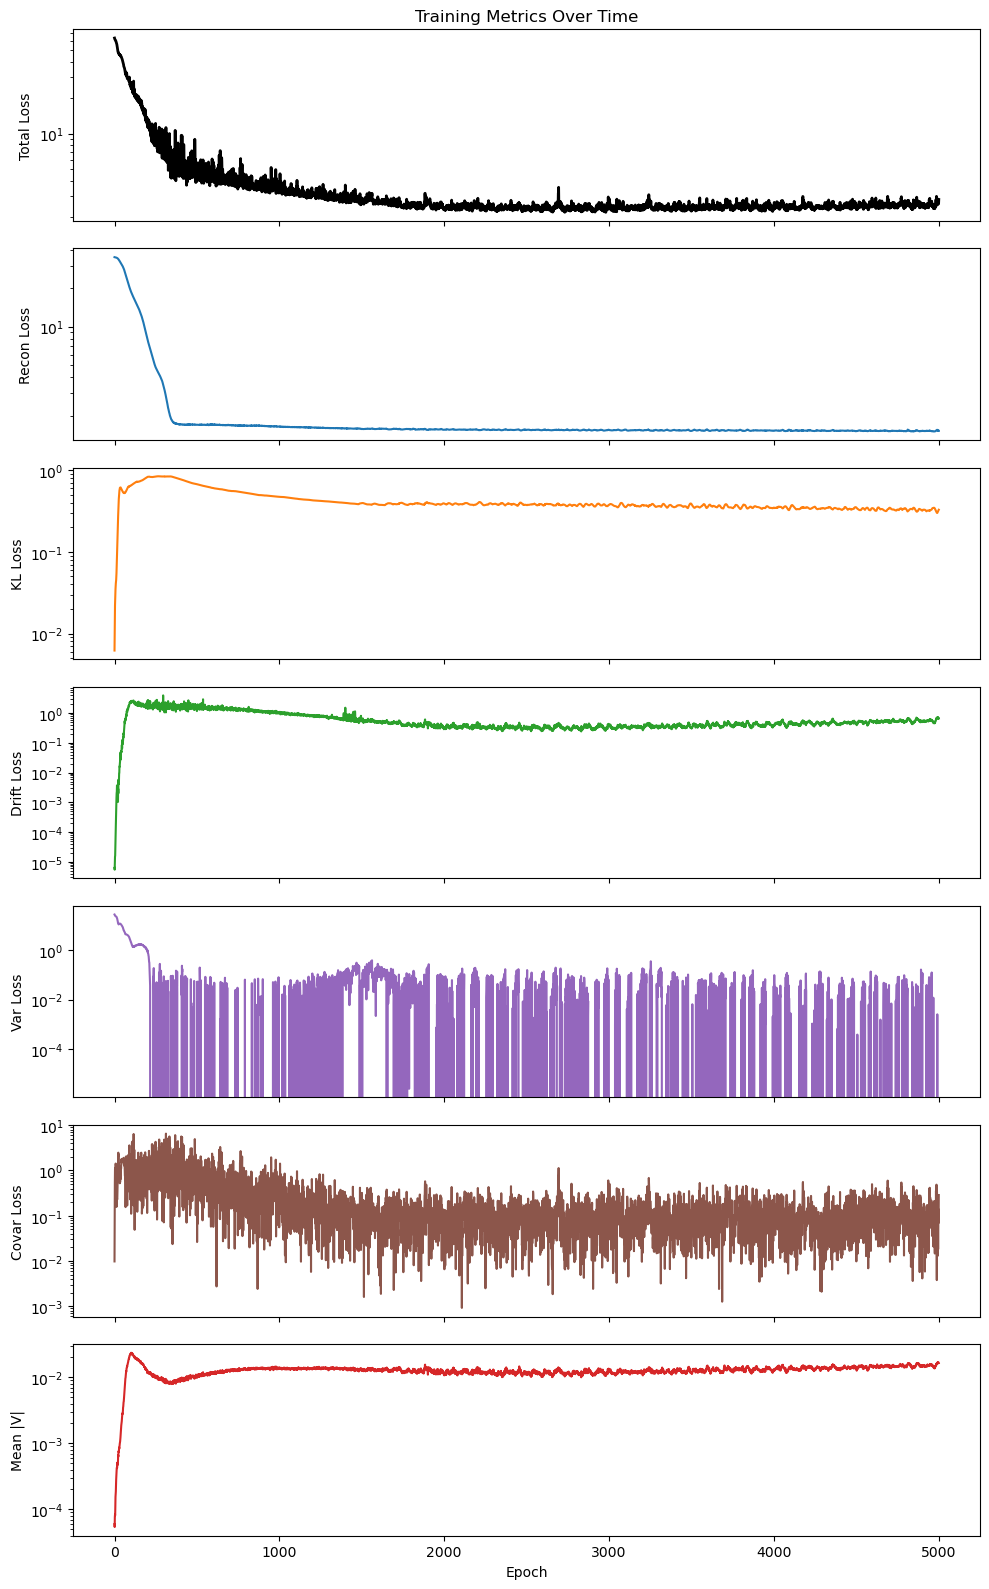

In [10]:
# 1. Helper function to safely extract floats
def to_float_list(data_list):
    return [x.item() if hasattr(x, 'item') else x for x in data_list]

# 2. Safely convert all lists
train_losses = to_float_list(train_losses)
recon_losses = to_float_list(recon_losses)
kl_losses = to_float_list(kl_losses)
drift_losses = to_float_list(drift_losses)
var_losses = to_float_list(var_losses)
covar_losses = to_float_list(covar_losses)
average_V = to_float_list(average_V)

# 3. Create 7 separate subplots stacked vertically
# We increase the figure height (e.g., 16) so they aren't squished
fig, axes = plt.subplots(7, 1, figsize=(10, 16), sharex=True)

# Total Loss
axes[0].plot(train_losses, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Metrics Over Time')

# Recon Loss
axes[1].plot(recon_losses, color='tab:blue')
axes[1].set_yscale('log')
axes[1].set_ylabel('Recon Loss')

# KL Loss
axes[2].plot(kl_losses, color='tab:orange')
axes[2].set_yscale('log')
axes[2].set_ylabel('KL Loss')

# Drift Loss
axes[3].plot(drift_losses, color='tab:green')
axes[3].set_yscale('log')
axes[3].set_ylabel('Drift Loss')

# Var Loss
axes[4].plot(var_losses, color='tab:purple')
axes[4].set_yscale('log')
axes[4].set_ylabel('Var Loss')

# Covar Loss
axes[5].plot(covar_losses, color='tab:brown')
axes[5].set_yscale('log')
axes[5].set_ylabel('Covar Loss')

# Average V (Drift Field Magnitude)
axes[6].plot(average_V, color='tab:red')
axes[6].set_yscale('log')
axes[6].set_ylabel('Mean |V|')
axes[6].set_xlabel('Epoch') # Only need x-label on the very bottom graph

plt.tight_layout()
plt.show()

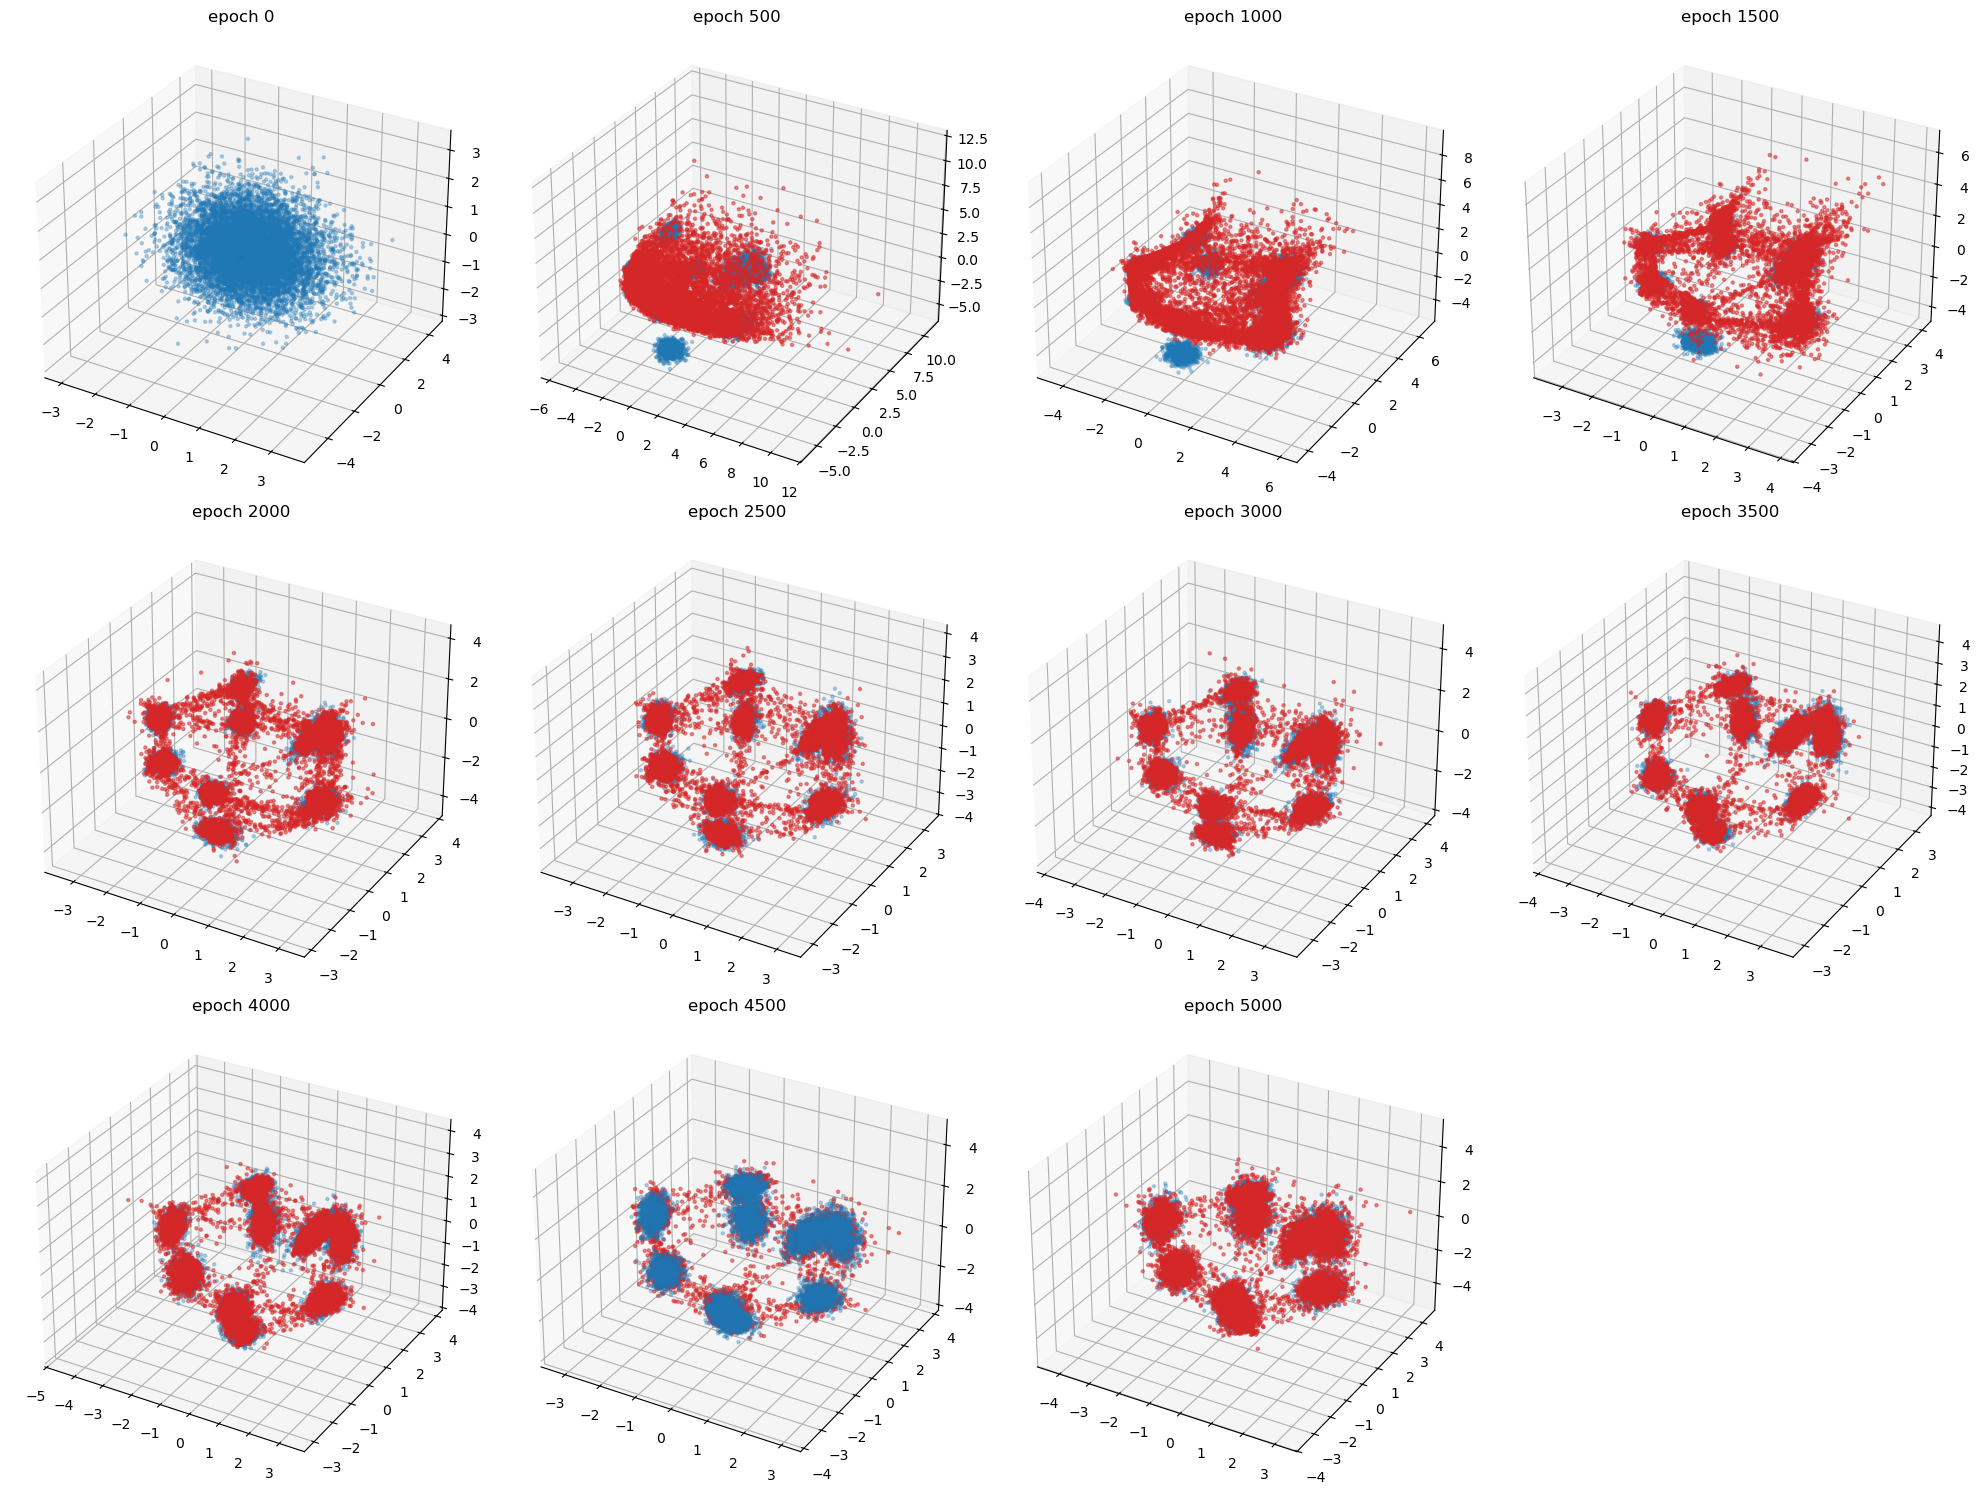

In [11]:
n_snaps = len(q_evolution)
n_cols = 4
n_rows = (n_snaps + n_cols - 1) // n_cols

fig = plt.figure(figsize=(5 * n_cols, 5 * n_rows))
for i, snap in enumerate(q_evolution):
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')
    ax.scatter(snap['pos'][:,0], snap['pos'][:,1], snap['pos'][:,2],
               c='tab:blue', alpha=0.3, s=5)
    ax.scatter(snap['neg'][:,0], snap['neg'][:,1], snap['neg'][:,2],
               c='tab:red', alpha=0.5, s=5)
    ax.set_title(f"epoch {snap.get('epoch', i)}")

plt.tight_layout()
plt.show()

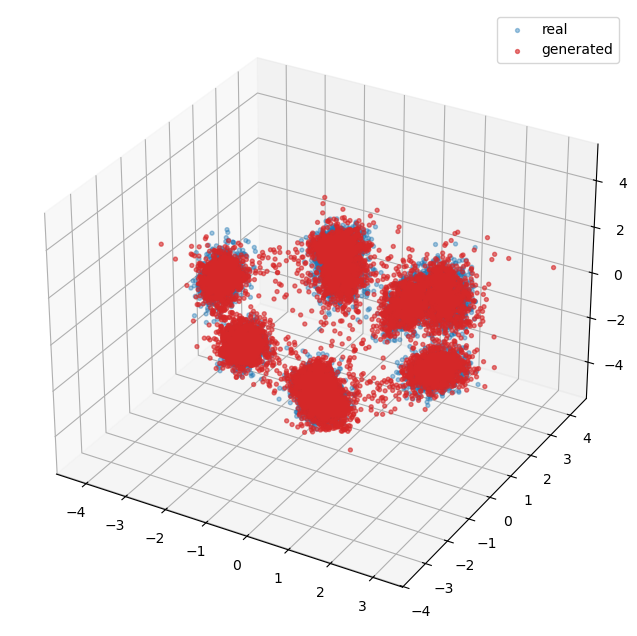

In [12]:
num_epochs = 5000
special_iterations = list(range(0, num_epochs + 1, 500))
if num_epochs not in special_iterations:
    special_iterations.append(num_epochs)
epoch_idx = special_iterations.index(5000)
snap = q_evolution[epoch_idx]
pos, neg = snap["pos"], snap["neg"]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:,0], pos[:,1], pos[:,2], c='tab:blue', alpha=0.4, s=8, label='real')
ax.scatter(neg[:,0], neg[:,1], neg[:,2], c='tab:red', alpha=0.6, s=8, label='generated')
ax.legend()
plt.show()

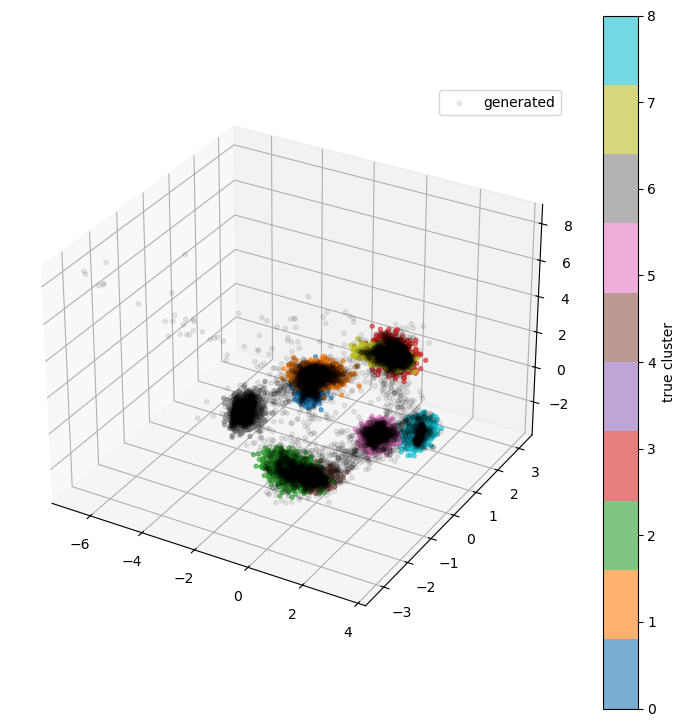

In [225]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pos[:,0], pos[:,1], pos[:,2], c=y, cmap='tab10', s=8, alpha=0.6)
ax.scatter(neg[:,0], neg[:,1], neg[:,2], c='black', s=10, alpha=0.08, label='generated')
plt.colorbar(sc, label='true cluster')
ax.legend()
plt.show()

In [18]:
model.eval()
with torch.no_grad():
    mu, logvar, y_pos_latent = model.get_latent(truth)
    y_pos_recon = model.decoder(y_pos_latent)

recon_per_sample = ((y_pos_recon - truth) ** 2).mean(dim=1)
y_t = torch.from_numpy(y).to(recon_per_sample.device)

for c in range(9):
    print(c, recon_per_sample[y_t == c].mean().item())

0 1.5310474634170532
1 1.5191762447357178
2 1.5101232528686523
3 1.5235437154769897
4 1.5458885431289673
5 1.5300074815750122
6 1.5855576992034912
7 1.5332659482955933
8 1.5330872535705566


## Now lets separate the VAE from the generator


In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim=3, input_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = input_dim

        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2)
        )

        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_var = nn.Linear(16, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, self.input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent

    def decode(self, latent):
        return self.decoder(latent)

    def forward(self, y):
        mu, logvar, latent = self.encode(y)
        reconstructed = self.decode(latent)
        return reconstructed, mu, logvar, latent

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=3):
        super().__init__()
        self.latent_dim = latent_dim

        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, self.latent_dim)
        )

    def forward(self, latent_input):
        # Maps latent noise to a target latent vector (or outputs a drift velocity)
        return self.generator(latent_input)

In [8]:
vae = VAE()
def train_vae(vae_model, truth, num_epochs, lambda_kl):
    vae_model.to(device)
    optimizer = optim.AdamW(vae_model.parameters(), lr=0.001)
    
    train_losses = []
    recon_losses = []
    kl_losses = []
    lambda_var=10.0
    lambda_cov=50.0
    print("--- VAE Training Started ---")
    
    for epoch in range(num_epochs + 1):
        vae_model.train()
        optimizer.zero_grad()

        # Forward pass
        y_pos_recon, mu, logvar, y_pos_latent = vae_model(truth)
        
        # 1. Recon Loss
        loss_recon = nn.MSELoss(reduction='none')(y_pos_recon, truth).sum(dim=1).mean()

        # 2. KL Loss
        loss_kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

        # 3. Variance & Covariance Losses (Applied to the VAE's latents!)
        # Replace these with your exact var/covar functions applied to y_pos_latent
        loss_var = variance_loss(mu) 
        loss_covar = covariance_loss(y_pos_latent)

        # 4. Total Fair VAE Loss
        loss = loss_recon + (lambda_kl * loss_kl) + (lambda_var * loss_var) + (lambda_cov * loss_covar)

        loss.backward()
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        recon_losses.append(loss_recon.item())
        kl_losses.append(loss_kl.item() * lambda_kl)
        
        if epoch < 20 or epoch % 50 == 0:
            print(f"-------- Epoch {epoch}--------")
            print(f"Loss summary:")
            print(f"total={epoch_loss:.4f}\n")
            print("Loss composition")
            print(f"Recon {loss_recon.item() * 100 / epoch_loss:.2f}%")
            print(f"Kl (scaled) {loss_kl.item() * lambda_kl * 100 / epoch_loss:.2f}%\n")
            print(f"recon loss: {loss_recon.item():.4f}")
            print(f"kl loss: {loss_kl.item():.4f}    kl loss scaled: {loss_kl.item() * lambda_kl:.4f}")
            print("y_pos spread:", y_pos_latent.std(dim=0).mean().item())
            print()
            
    print("VAE Training Finished")
    return vae_model, train_losses, recon_losses, kl_losses

In [78]:
vae, train_losses, recon_losses, kl_losses =  train_vae(vae, truth, 3000, lambda_kl=0.001)

--- VAE Training Started ---
-------- Epoch 0--------
Loss summary:
total=4484.7471

Loss composition
Recon 99.82%
Kl (scaled) 0.00%

recon loss: 4476.8643
kl loss: 0.5388    kl loss scaled: 0.0005
y_pos spread: 1.185699701309204

-------- Epoch 1--------
Loss summary:
total=4479.9155

Loss composition
Recon 99.84%
Kl (scaled) 0.00%

recon loss: 4472.9624
kl loss: 0.6291    kl loss scaled: 0.0006
y_pos spread: 1.2154076099395752

-------- Epoch 2--------
Loss summary:
total=4475.0293

Loss composition
Recon 99.86%
Kl (scaled) 0.00%

recon loss: 4468.9243
kl loss: 0.7967    kl loss scaled: 0.0008
y_pos spread: 1.2723026275634766

-------- Epoch 3--------
Loss summary:
total=4469.7329

Loss composition
Recon 99.88%
Kl (scaled) 0.00%

recon loss: 4464.3706
kl loss: 1.0300    kl loss scaled: 0.0010
y_pos spread: 1.337113618850708

-------- Epoch 4--------
Loss summary:
total=4464.2129

Loss composition
Recon 99.89%
Kl (scaled) 0.00%

recon loss: 4459.4722
kl loss: 1.3134    kl loss scaled:

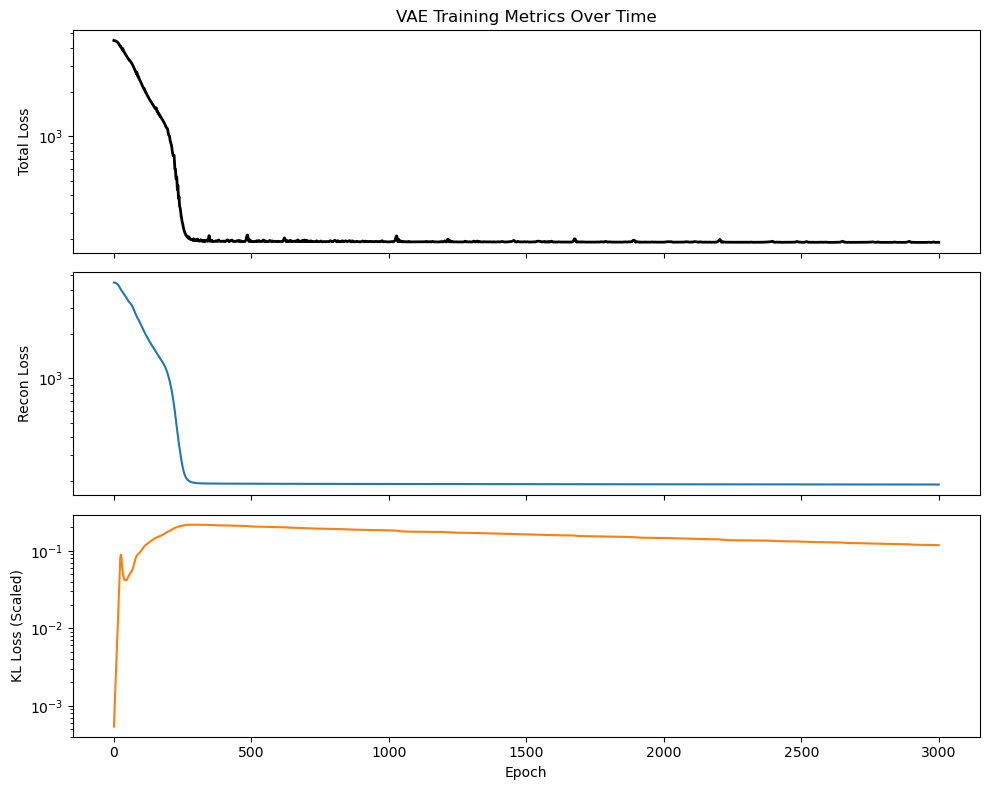

In [79]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Total Loss
axes[0].plot(train_losses, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('VAE Training Metrics Over Time')

# Recon Loss
axes[1].plot(recon_losses, color='tab:blue', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Recon Loss')

# KL Loss
axes[2].plot(kl_losses, color='tab:orange', linewidth=1.5)
axes[2].set_yscale('log')
axes[2].set_ylabel('KL Loss (Scaled)')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [90]:
gen = Generator()
def train_generator(drift_model, trained_vae, truth, num_epochs, temp, lambda_drift=1.0, num_samples_total=len(truth)):
    drift_model.to(device)
    trained_vae.eval() # Freeze the VAE
    optimizer = optim.AdamW(drift_model.parameters(), lr=0.001)
    
    train_losses = []
    average_V = []
    q_evolution = []
    
    special_iterations = list(range(0, num_epochs + 1, 500))
    if num_epochs not in special_iterations:
        special_iterations.append(num_epochs)
        
    print("--- Pure Drift Generator Training Started ---")
    
    # Pre-compute the target latents once since the VAE is frozen
    with torch.no_grad():
        _, _, target_latents = trained_vae.encode(truth)
    
    for epoch in range(num_epochs + 1):
        drift_model.train()
        optimizer.zero_grad()

        # Generate noise in the LATENT dimension (e.g., 3)
        noise = torch.randn(num_samples_total, drift_model.latent_dim, device=device)
        y_neg_latent = drift_model(noise)
        
        # Calculate ONLY your pure drift loss and the vector field V
        # Replace this with your actual pure drift loss function
        loss_drift, V = drift_loss(y_neg_latent, target_latents, temp)
        
        # Since it is the only loss, total loss IS the drift loss (scaled if you want to keep lambda)
        loss = loss_drift * lambda_drift
        
        loss.backward()
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        # Assuming your function returns V for tracking:
        average_V.append(V.norm(dim=1).mean().item()) 
        
        if epoch in special_iterations:
            q_evolution.append({
                "epoch": epoch,
                "pos": target_latents.detach().cpu().numpy(),
                "neg": y_neg_latent.detach().cpu().numpy(),
            })
            
        if epoch < 20 or epoch % 50 == 0:
            print(f"-------- Epoch {epoch} --------")
            print(f"Total Loss (Pure Drift): {epoch_loss:.10f}")
            # print(f"Average force magnitude (V): {V.norm(dim=1).mean().item():.4f}")
            print(f"Target Latent Spread: {target_latents.std(dim=0).mean().item():.4f}")
            print(f"Generated Latent Spread: {y_neg_latent.std(dim=0).mean().item():.4f}")
            print()
            
    print("Drift Training Finished")
    return drift_model, train_losses, average_V, q_evolution

In [91]:
gen, train_losses, average_V, q_evolution = train_generator(gen, vae, truth, 3000, 1)

--- Pure Drift Generator Training Started ---
-------- Epoch 0 --------
Total Loss (Pure Drift): 0.0000160908
Target Latent Spread: 6.5420
Generated Latent Spread: 0.0037

-------- Epoch 1 --------
Total Loss (Pure Drift): 0.0000162060
Target Latent Spread: 6.5420
Generated Latent Spread: 0.0037

-------- Epoch 2 --------
Total Loss (Pure Drift): 0.0000163375
Target Latent Spread: 6.5420
Generated Latent Spread: 0.0038

-------- Epoch 3 --------
Total Loss (Pure Drift): 0.0000164829
Target Latent Spread: 6.5420
Generated Latent Spread: 0.0041

-------- Epoch 4 --------
Total Loss (Pure Drift): 0.0000166470
Target Latent Spread: 6.5420
Generated Latent Spread: 0.0046

-------- Epoch 5 --------
Total Loss (Pure Drift): 0.0000168295
Target Latent Spread: 6.5420
Generated Latent Spread: 0.0053

-------- Epoch 6 --------
Total Loss (Pure Drift): 0.0000170516
Target Latent Spread: 6.5420
Generated Latent Spread: 0.0062

-------- Epoch 7 --------
Total Loss (Pure Drift): 0.0000172787
Target L

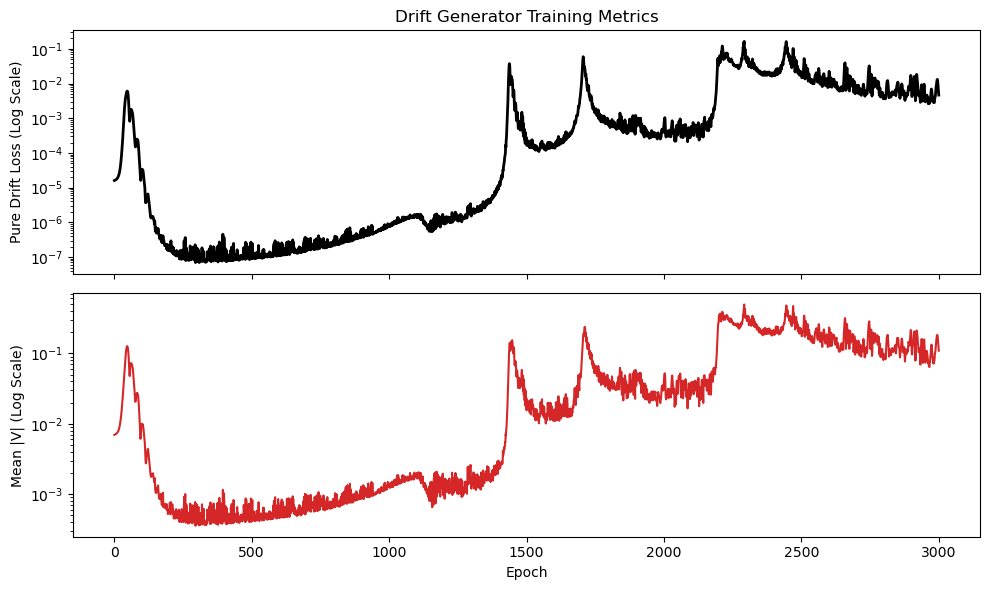

In [92]:

# Assuming you just ran the drift training loop:
# drift_model, train_losses, average_V, q_evolution = train_pure_drift_generator(...)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Top Graph: Pure Drift Loss
axes[0].plot(train_losses, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Pure Drift Loss (Log Scale)')
axes[0].set_title('Drift Generator Training Metrics')

# Bottom Graph: Average V (Drift Field Magnitude)
axes[1].plot(average_V, color='tab:red', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Mean |V| (Log Scale)')
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

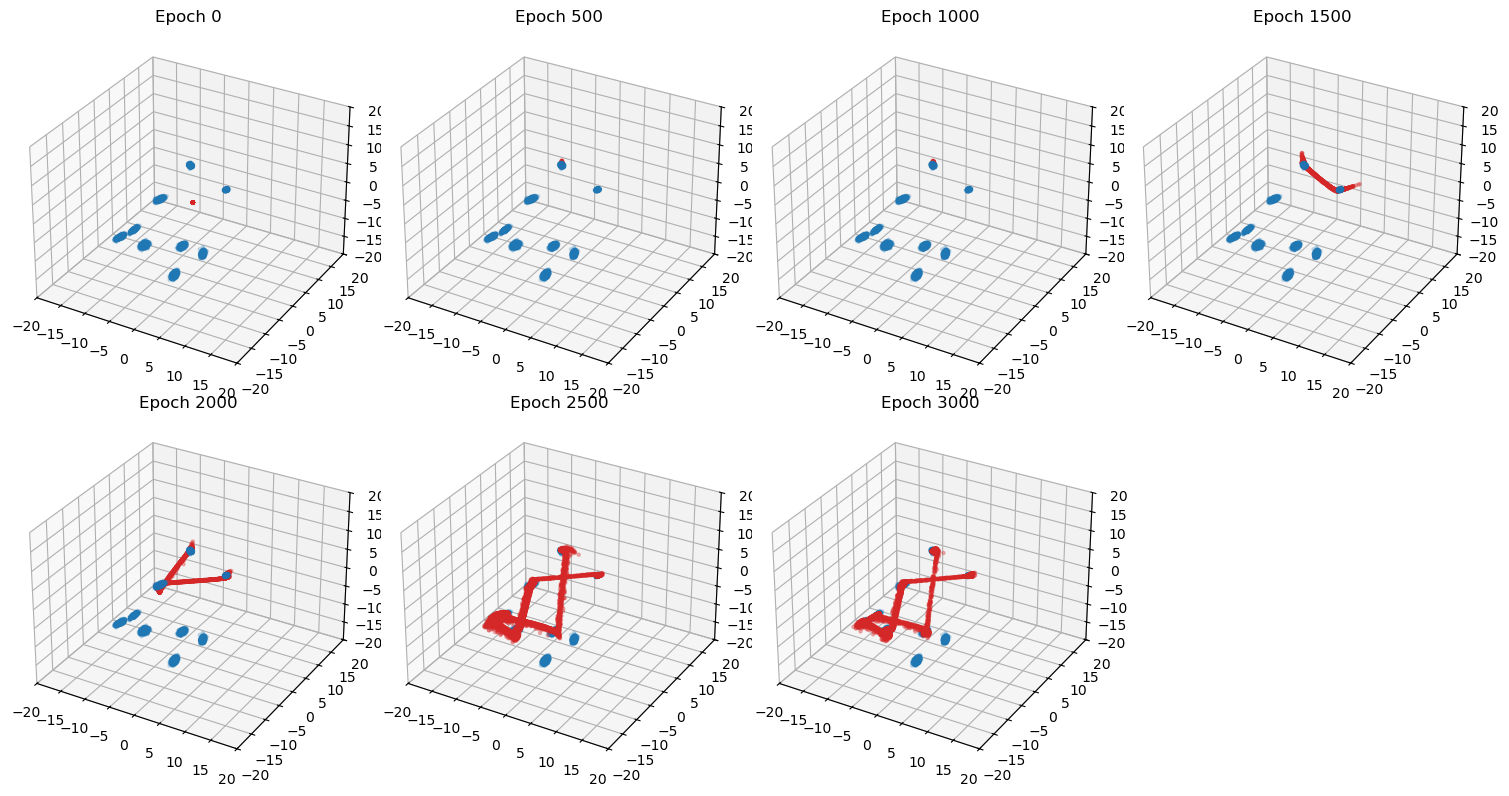

In [94]:
# Calculate grid size based on how many snapshots we saved
num_plots = len(q_evolution)
cols = 4 
rows = (num_plots + cols - 1) // cols

# Create the figure
fig = plt.figure(figsize=(15, 4 * rows))

for i, step in enumerate(q_evolution):
    epoch = step["epoch"]
    pos = step["pos"]  # The frozen target latents from the VAE (blue)
    neg = step["neg"]  # The generated noise/latents from the Drift model (red)

    # Create a 3D subplot for each snapshot
    ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
    
    # Plot target VAE clusters
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], 
               c='tab:blue', alpha=0.2, s=5, label='Target (VAE)')
    
    # Plot generated Drift points
    ax.scatter(neg[:, 0], neg[:, 1], neg[:, 2], 
               c='tab:red', alpha=0.3, s=5, label='Generated')
    
    ax.set_title(f'Epoch {epoch}')
    
    # Set consistent axis limits so the camera doesn't zoom in/out between frames
    # (Adjust these limits if your latent space expanded beyond -4 to 4)
    ax.set_xlim([-20, 20])
    ax.set_ylim([-20, 20])
    ax.set_zlim([-20, 20])

plt.tight_layout()
plt.show()

In [85]:
# 1. Set the separated VAE to evaluation mode
vae.eval()

with torch.no_grad():
    # 2. Get the latent representation and the reconstruction
    mu, logvar, y_pos_latent = vae.encode(truth)
    y_pos_recon = vae.decode(y_pos_latent)

# 3. Calculate the Mean Squared Error per sample
recon_per_sample = ((y_pos_recon - truth) ** 2).mean(dim=1)

# Ensure your label array 'y' is on the same device
y_t = torch.from_numpy(y).to(recon_per_sample.device)

# 4. Print the average reconstruction error for each cluster
print("VAE Reconstruction Error per Cluster:")
for c in range(9):
    # Check if the cluster exists in the current batch to avoid NaNs
    if (y_t == c).sum() > 0:
        cluster_error = recon_per_sample[y_t == c].mean().item()
        print(f"Cluster {c}: {cluster_error:.4f}")
    else:
        print(f"Cluster {c}: No samples in batch")

VAE Reconstruction Error per Cluster:
Cluster 0: 1.4852
Cluster 1: 1.4822
Cluster 2: 1.4762
Cluster 3: 1.4716
Cluster 4: 1.4773
Cluster 5: 1.4767
Cluster 6: 1.4962
Cluster 7: 1.4846
Cluster 8: 1.4758


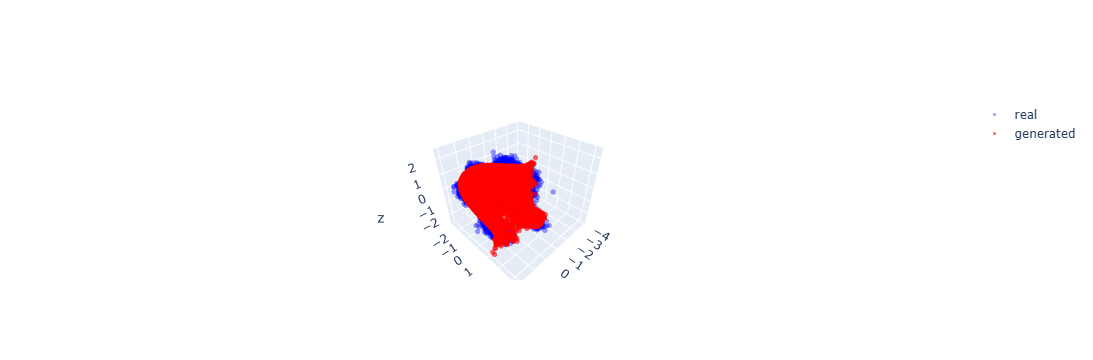

In [195]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=pos[:,0], y=pos[:,1], z=pos[:,2],
              mode='markers', marker=dict(size=3, color='blue', opacity=0.4), name='real'))
fig.add_trace(go.Scatter3d(x=neg[:,0], y=neg[:,1], z=neg[:,2],
              mode='markers', marker=dict(size=3, color='red', opacity=0.6), name='generated'))
fig.show()

Ideas to try out:
- Stop the VAE half way through the epochs
- topological encoder
- increase the high dimension
- Better way to meassure reconstruction success?
- test against vae first then drift end to end vs vae focused
- try this on cifar10
- use clusters of initial noise, Gaussian Mixture Model (GMM)

# Joint image generation


In [192]:
import torch
import torch.nn as nn

class JointModel(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # 32 -> 16
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16 -> 8
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8 -> 4
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(2048, latent_dim)
        self.fc_var = nn.Linear(2048, latent_dim)

        # self.decoder_input = nn.Linear(latent_dim, 2048)
        self.decoder_input = nn.Linear(latent_dim, 256 * 4 * 4)


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),   # 4 -> 8
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
    
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),    # 8 -> 16
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
    
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),     # 16 -> 32
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
    
            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),
            ## nn.Sigmoid()
            nn.Tanh() #output between -1 and 1 for svhm
        )

        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.SiLU(),
            nn.Linear(512, latent_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def get_latent(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent

    def decode(self, z):
        z = self.decoder_input(z)
        # z = z.view(z.size(0), 128, 4, 4)
        z = z.view(z.size(0), 256, 4, 4)
        return self.decoder(z)

    def generate(self, noise):
        generated_latent = self.generator(noise)
        generated_final = self.decode(generated_latent)
        return generated_latent, generated_final

C:\Users\mateo\AppData\Local\Temp\ipykernel_26000\2633093337.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Total deer images extracted: 5000
Single sample shape: (32, 32, 3)
Data type: uint8


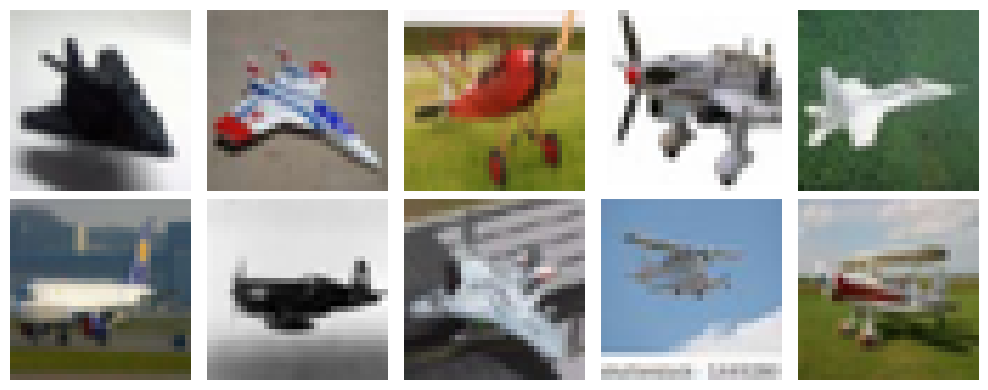

In [57]:
import pickle

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

all_deer_images = []

# Loop through all 5 training batches
for i in range(1, 6):
    batch = unpickle(f'../image_gen/cifar-10-batches-py/data_batch_{i}')
    
    raw_images = batch[b'data']
    labels = np.array(batch[b'labels'])
    
    # Filter indices where label is 4 (deer)
    # 0 is airplane
    deer_indices = np.where(labels == 4)[0]
    
    # Extract, reshape, and transpose those specific images
    filtered_images = raw_images[deer_indices].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    all_deer_images.append(filtered_images)

# Concatenate all batches into a single array
deer_dataset = np.concatenate(all_deer_images, axis=0)

print(f"Total deer images extracted: {deer_dataset.shape[0]}")
print("Single sample shape:", deer_dataset[0].shape)
print("Data type:", deer_dataset.dtype)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(deer_dataset[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [97]:
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader

deer_tensor = torch.from_numpy(deer_dataset).permute(0, 3, 1, 2).float() / 255.0
dataset = TensorDataset(deer_tensor)


loader = DataLoader(
    dataset, 
    batch_size=500, 
    shuffle=True, 
    drop_last=True, 
    num_workers=0,
    pin_memory=True       # Speeds up the transfer of data from CPU to GPU
)

In [135]:
model = JointModel(latent_dim=100) # Ensure latent_dim matches your noise shape
mse = nn.MSELoss(reduction='mean')
optimizer = optim.AdamW(model.parameters(), lr=0.001)
num_epochs = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
def training_loop(num_epochs, temp, lambda_kl, lambda_drift, lambda_var, lambda_cov, loader):
    model.to(device)
    train_losses = []
    recon_losses = []
    kl_losses = []
    drift_losses = []
    var_losses = []
    covar_losses = []
    average_V = []
    
    print("Training started")

    for epoch in range(num_epochs + 1):
        model.train()
        
        # Accumulators for the mini-batches
        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        epoch_drift = 0.0
        epoch_var = 0.0
        epoch_covar = 0.0
        epoch_v = 0.0
        
        # Iterate over mini-batches
        for (truth,) in loader:
            truth = truth.to(device)
            curr_batch_size = truth.size(0)
            
            # Generate noise matching current batch size and latent dim
            noise = torch.randn(curr_batch_size, model.latent_dim, device=device)
            
            optimizer.zero_grad()

            # Forward passes
            mu, logvar, y_pos_latent = model.get_latent(truth)
            # y_pos_latent_detached = y_pos_latent.detach()   # drift sees this, but no gradient flows back into encoder from it
            y_pos_recon = model.decode(y_pos_latent)
            y_neg_latent, y_neg_recon = model.generate(noise)
            
            # Loss calculation
            loss, loss_items = total_loss(y_pos_recon, truth, mu, logvar, y_neg_latent, y_pos_latent, temp,
                                          lambda_kl, lambda_drift, lambda_var, lambda_cov)
            loss.backward()
            optimizer.step()
            
            # Accumulate metrics
            epoch_loss += loss.item()
            epoch_recon += loss_items["recon"].item()
            epoch_kl += loss_items["kl"].item() * lambda_kl
            epoch_drift += loss_items["drift"].item() * lambda_drift
            epoch_var += loss_items["var"].item() * lambda_var
            epoch_covar += loss_items["covar"].item() * lambda_cov
            epoch_v += loss_items["V"].norm(dim=1).mean().item()
            
        # Average the accumulated losses over the number of batches
        num_batches = len(loader)
        avg_epoch_loss = epoch_loss / num_batches
        avg_items = {
            "recon": epoch_recon / num_batches,
            "kl": epoch_kl / num_batches,  # Already scaled above
            "drift": epoch_drift / num_batches, # Already scaled above
            "var": epoch_var / num_batches, # Already scaled above
            "covar": epoch_covar / num_batches, # Already scaled above
            "V_mag": epoch_v / num_batches
        }

        scheduler.step()
        
        # Append to histories
        train_losses.append(avg_epoch_loss)
        recon_losses.append(avg_items["recon"])
        kl_losses.append(avg_items["kl"])
        drift_losses.append(avg_items["drift"])
        var_losses.append(avg_items["var"])
        covar_losses.append(avg_items["covar"])
        average_V.append(avg_items["V_mag"])
        
        
        if epoch < 20 or epoch % 50 == 0:
            print(f"-------- Epoch {epoch}--------")
            print(f"Loss summary:")
            print(f"total={avg_epoch_loss:.4f}\n")
            print("Loss composition")
            print(f"Recon {avg_items['recon'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Kl (scaled) {avg_items['kl'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Drift (scaled) {avg_items['drift'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Var (scaled) {avg_items['var'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Covar (scaled) {avg_items['covar'] * 100 / avg_epoch_loss:.2f}%\n")
            
            print(f"recon loss: {avg_items['recon']:.10f}")
            print(f"kl loss scaled: {avg_items['kl']:.10f}")
            print(f"drift loss scaled: {avg_items['drift']:.10f}")
            print(f"var loss scaled: {avg_items['var']:.10f}")
            print(f"covar loss scaled: {avg_items['covar']:.10f}")
            print("Average force magnitude across all points (V): ", avg_items["V_mag"])
            
            # Stats computed on the final batch of the epoch
            print("distances (last batch):", torch.cdist(y_pos_latent[:50], y_pos_latent[:50]).mean().item())
            print("y_neg spread (last batch):", y_neg_latent.std(dim=0).mean().item())
            print("y_pos spread (last batch):", y_pos_latent.std(dim=0).mean().item())
            print()
            
    print("Finished")
    return model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V

In [136]:
num_epochs = 1000
temp = 22
lambda_kl = 0.01
lambda_var = 60.0
lambda_cov = 1.0
lambda_drift = 0.5
model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V = training_loop(
    num_epochs=num_epochs,
    temp=temp,
    lambda_kl=lambda_kl,
    lambda_drift=lambda_drift,
    lambda_var=lambda_var,
    lambda_cov=lambda_cov,
    loader=loader,
)


Training started
-------- Epoch 0--------
Loss summary:
total=3.1933

Loss composition
Recon 2.13%
Kl (scaled) 13.28%
Drift (scaled) 0.11%
Var (scaled) 82.10%
Covar (scaled) 2.39%

recon loss: 0.0679861553
kl loss scaled: 0.4241082439
drift loss scaled: 0.0034110588
var loss scaled: 2.6215857029
covar loss scaled: 0.0762242336
Average force magnitude across all points (V):  1.8235508441925048
distances (last batch): 32.4118537902832
y_neg spread (last batch): 0.1687755137681961
y_pos spread (last batch): 1.0262248516082764

-------- Epoch 1--------
Loss summary:
total=2.8350

Loss composition
Recon 2.23%
Kl (scaled) 5.15%
Drift (scaled) 0.06%
Var (scaled) 89.76%
Covar (scaled) 2.80%

recon loss: 0.0630836349
kl loss scaled: 0.1461111364
drift loss scaled: 0.0017886819
var loss scaled: 2.5445737600
covar loss scaled: 0.0794208981
Average force magnitude across all points (V):  1.3430360913276673
distances (last batch): 31.85573959350586
y_neg spread (last batch): 0.3100614547729492
y_po

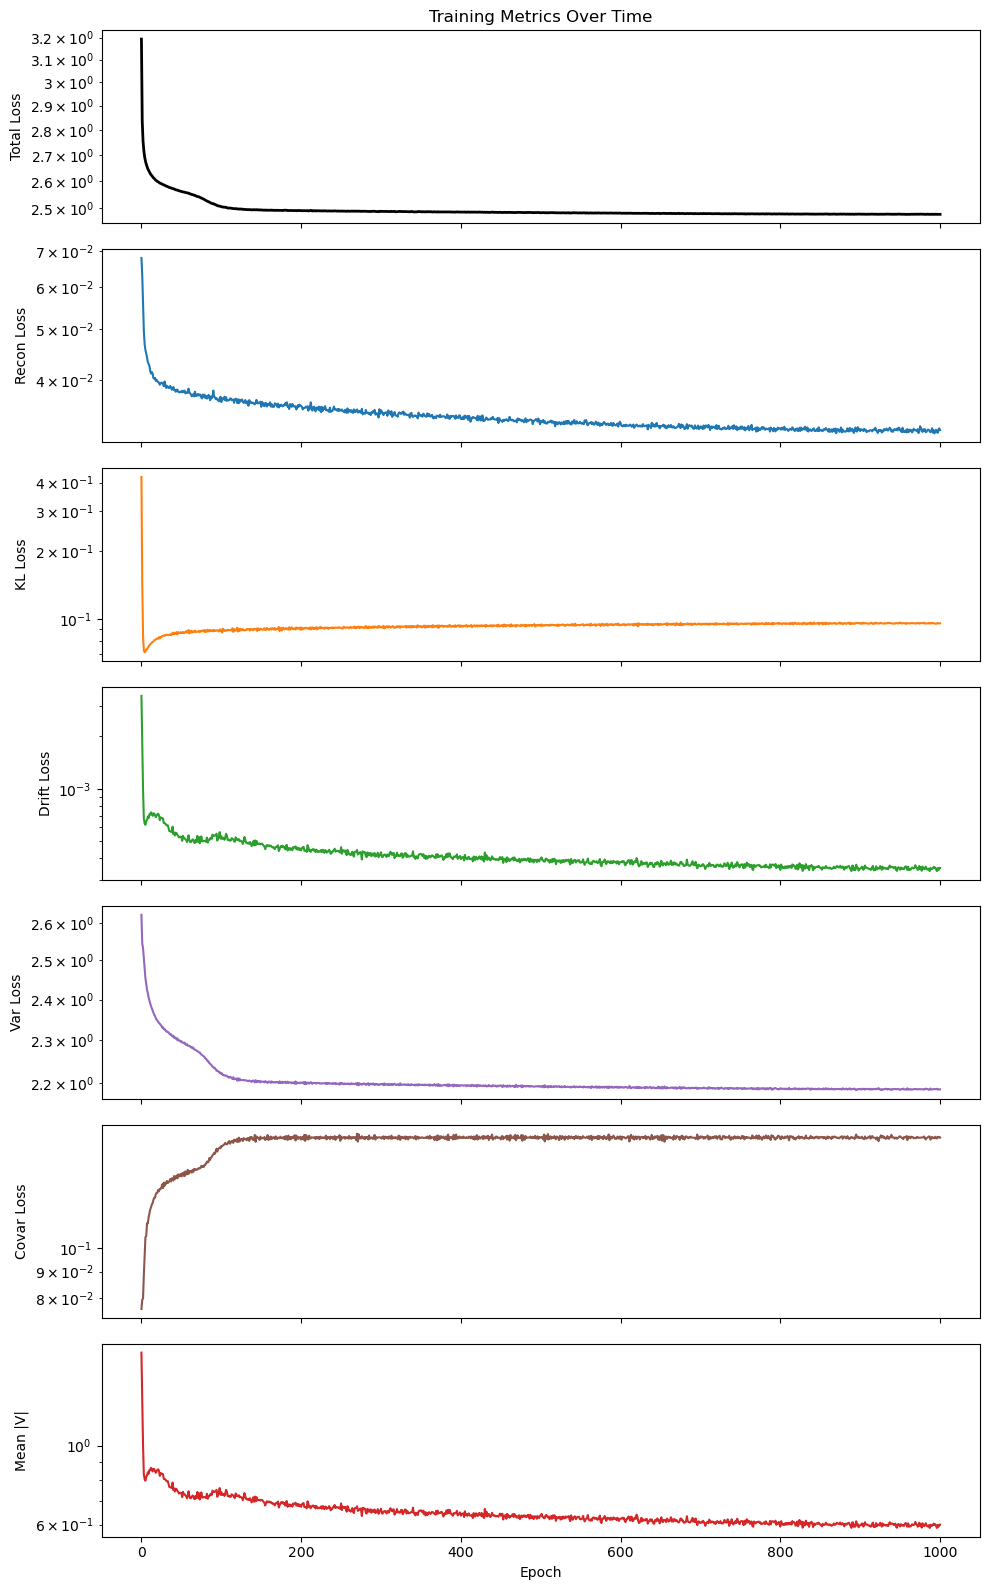

In [137]:
def to_float_list(data_list):
    return [x.item() if hasattr(x, 'item') else x for x in data_list]

train_losses = to_float_list(train_losses)
recon_losses = to_float_list(recon_losses)
kl_losses = to_float_list(kl_losses)
drift_losses = to_float_list(drift_losses)
var_losses = to_float_list(var_losses)
covar_losses = to_float_list(covar_losses)
average_V = to_float_list(average_V)

# 3. Create 7 separate subplots stacked vertically
# We increase the figure height (e.g., 16) so they aren't squished
fig, axes = plt.subplots(7, 1, figsize=(10, 16), sharex=True)

# Total Loss
axes[0].plot(train_losses, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Metrics Over Time')

# Recon Loss
axes[1].plot(recon_losses, color='tab:blue')
axes[1].set_yscale('log')
axes[1].set_ylabel('Recon Loss')

# KL Loss
axes[2].plot(kl_losses, color='tab:orange')
axes[2].set_yscale('log')
axes[2].set_ylabel('KL Loss')

# Drift Loss
axes[3].plot(drift_losses, color='tab:green')
axes[3].set_yscale('log')
axes[3].set_ylabel('Drift Loss')

# Var Loss
axes[4].plot(var_losses, color='tab:purple')
axes[4].set_yscale('log')
axes[4].set_ylabel('Var Loss')

# Covar Loss
axes[5].plot(covar_losses, color='tab:brown')
axes[5].set_yscale('log')
axes[5].set_ylabel('Covar Loss')

# Average V (Drift Field Magnitude)
axes[6].plot(average_V, color='tab:red')
axes[6].set_yscale('log')
axes[6].set_ylabel('Mean |V|')
axes[6].set_xlabel('Epoch') # Only need x-label on the very bottom graph

plt.tight_layout()
plt.show()

In [54]:
def plot_direct_reconstructions(model, loader, num_images=5):
    """
    Plots real CIFAR-10 images directly next to their VAE reconstructions.
    Completely bypasses the noise sampling and drift generator.
    """
    model.eval() # Ensure dropout and batchnorm are in eval mode
    with torch.no_grad():
        # 1. Grab a single batch from your dataloader
        # Assuming your loader returns (images, labels) or just images
        batch = next(iter(loader))
        if isinstance(batch, list) or isinstance(batch, tuple):
            real_images = batch[0]
        else:
            real_images = batch
            
        real_images = real_images[:num_images].to(device)
        
        # 2. Push directly through the VAE (Encoder -> Decoder)
        _, _, latent_z = model.get_latent(real_images)
        reconstructed_images = model.decode(latent_z)
        
        # 3. Format for Matplotlib (Move to CPU, reshape C,H,W to H,W,C)
        real_np = real_images.cpu().permute(0, 2, 3, 1).numpy()
        recon_np = reconstructed_images.cpu().permute(0, 2, 3, 1).numpy()
        
        # 4. Plot the comparison grid
        fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2.5, 5))
        fig.suptitle("Direct VAE Reconstructions (Top: Real | Bottom: Recon)", fontsize=16)
        
        for i in range(num_images):
            # Top row: Real Images
            axes[0, i].imshow(real_np[i])
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title("Real", fontweight='bold')
            
            # Bottom row: Reconstructed Images
            axes[1, i].imshow(recon_np[i])
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title("Recon", fontweight='bold')
                
        plt.tight_layout()
        plt.show()

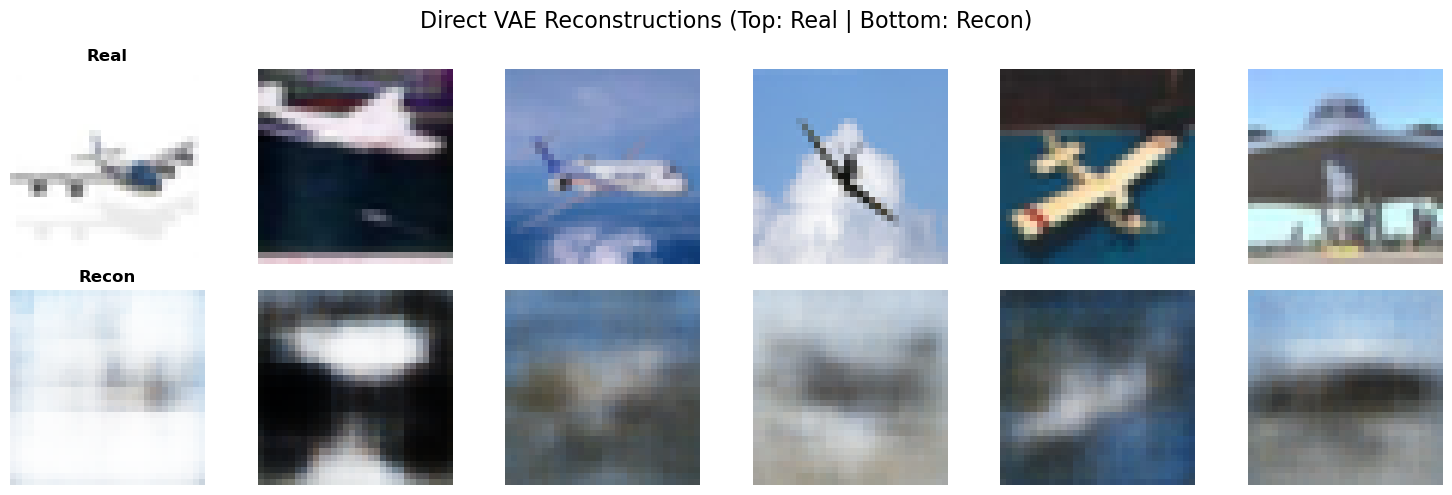

In [138]:
plot_direct_reconstructions(model, loader, num_images=6)

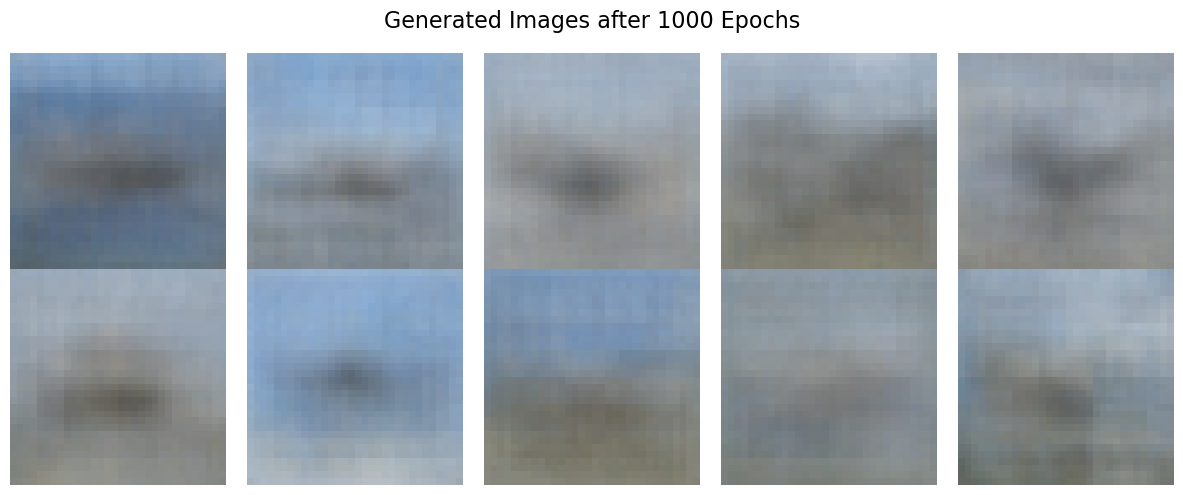

In [139]:
# 4. Generate and visualize exactly what the model learned
model.eval()
with torch.no_grad():
    # Sample random noise for 10 new images (Batch, Latent_Dim)
    sample_noise = torch.randn(10, model.latent_dim, device=device)
    
    # Generate the images purely from the noise
    _, generated_images = model.generate(sample_noise)
    
    # Move to CPU, reshape from (N, C, H, W) to (N, H, W, C) for Matplotlib
    generated_images = generated_images.cpu().permute(0, 2, 3, 1).numpy()

    # Plot the grid
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f"Generated Images after {num_epochs} Epochs", fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Training the pure VAE

In [132]:
model = JointModel(latent_dim=512).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

def train_vae_only(num_epochs, real_loader):
    model.train()
    losses = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for (real_x,) in real_loader:   # assuming you have a DataLoader; see note below
            real_x = real_x.to(device)
            optimizer.zero_grad()

            mu, logvar, z = model.get_latent(real_x)
            x_recon = model.decode(z)

            L_recon = F.mse_loss(x_recon, real_x, reduction='mean')
            L_kl = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())
            loss = L_recon + 0.01 * L_kl   # small kl weight to start, tune later

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss / len(real_loader))
        if epoch % 10 == 0:
            print(f"epoch {epoch}: recon={L_recon.item():.4f} kl={L_kl.item():.4f}")
    return model, losses

In [133]:
model, losses = train_vae_only(1000, loader)

epoch 0: recon=0.0333 kl=0.1908
epoch 10: recon=0.0131 kl=0.2898
epoch 20: recon=0.0099 kl=0.2837
epoch 30: recon=0.0083 kl=0.2664
epoch 40: recon=0.0079 kl=0.2617
epoch 50: recon=0.0071 kl=0.2595
epoch 60: recon=0.0064 kl=0.2600
epoch 70: recon=0.0061 kl=0.2601
epoch 80: recon=0.0057 kl=0.2648
epoch 90: recon=0.0057 kl=0.2670
epoch 100: recon=0.0057 kl=0.2675
epoch 110: recon=0.0052 kl=0.2682
epoch 120: recon=0.0050 kl=0.2678
epoch 130: recon=0.0053 kl=0.2697
epoch 140: recon=0.0048 kl=0.2738
epoch 150: recon=0.0048 kl=0.2692
epoch 160: recon=0.0047 kl=0.2732
epoch 170: recon=0.0049 kl=0.2715
epoch 180: recon=0.0046 kl=0.2714
epoch 190: recon=0.0047 kl=0.2713
epoch 200: recon=0.0046 kl=0.2685
epoch 210: recon=0.0044 kl=0.2738
epoch 220: recon=0.0043 kl=0.2762
epoch 230: recon=0.0044 kl=0.2750
epoch 240: recon=0.0046 kl=0.2732
epoch 250: recon=0.0043 kl=0.2743
epoch 260: recon=0.0043 kl=0.2754
epoch 270: recon=0.0042 kl=0.2687
epoch 280: recon=0.0043 kl=0.2700
epoch 290: recon=0.0040 k

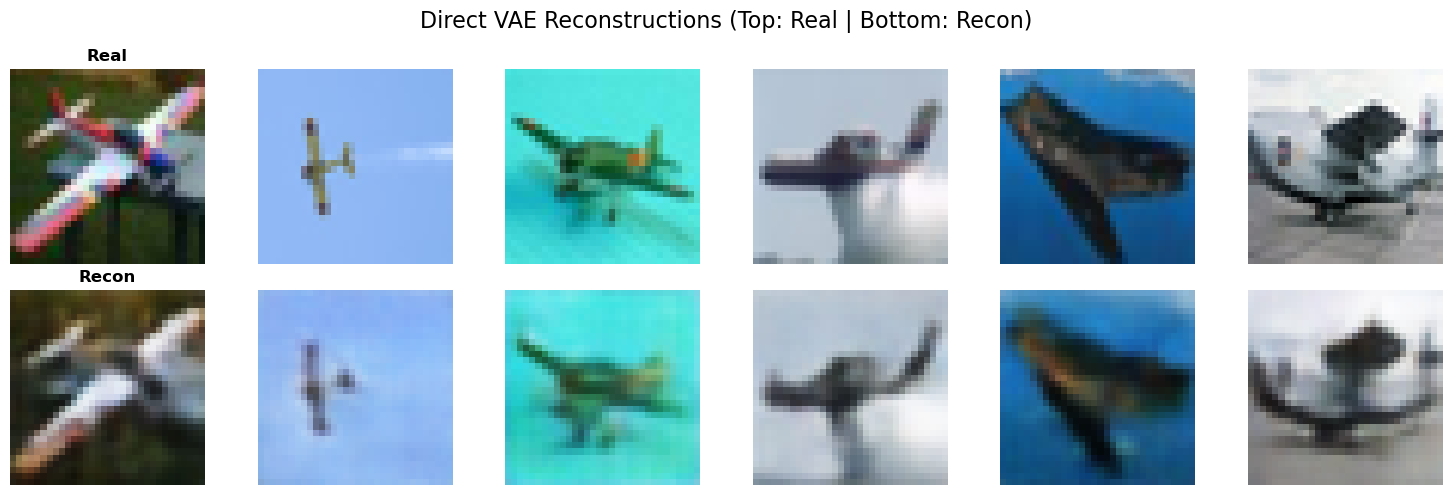

In [134]:
plot_direct_reconstructions(model, loader, num_images=6)

In [176]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset # Import Subset

# 1. Set up transforms
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Load full SVHN Dataset
svhn_train = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)

# 3. Create a subset with the first 10,000 indices
svhn_subset = Subset(svhn_train, range(10000))

# 4. Create DataLoader using the subset
dataloader = DataLoader(svhn_subset, batch_size=128, shuffle=True)


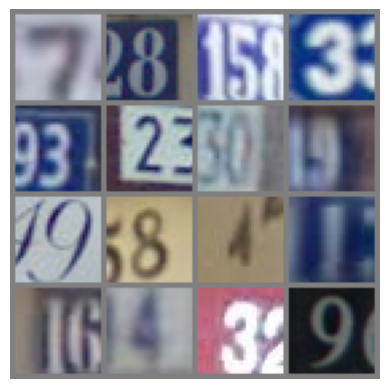

In [179]:
dataiter = iter(dataloader)
images, labels = next(dataiter)

# Function to unnormalize and display
def imshow(img):
    img = img / 2 + 0.5  # unnormalize back to [0, 1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Show the first 16 images in a grid
imshow(torchvision.utils.make_grid(images[:16], nrow=4))

In [193]:
model = JointModel(latent_dim=64) # Ensure latent_dim matches your noise shape
mse = nn.MSELoss(reduction='mean')
optimizer = optim.AdamW(model.parameters(), lr=0.001)
num_epochs = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
def training_loop(num_epochs, temp, lambda_kl, lambda_drift, lambda_var, lambda_cov, loader):
    model.to(device)
    train_losses = []
    recon_losses = []
    kl_losses = []
    drift_losses = []
    var_losses = []
    covar_losses = []
    average_V = []
    
    print("Training started")

    for epoch in range(num_epochs + 1):
        model.train()
        
        # Accumulators for the mini-batches
        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        epoch_drift = 0.0
        epoch_var = 0.0
        epoch_covar = 0.0
        epoch_v = 0.0
        
        # Iterate over mini-batches
        for truth, _ in dataloader:
            truth = truth.to(device)
            curr_batch_size = truth.size(0)
            
            # Generate noise matching current batch size and latent dim
            noise = torch.randn(curr_batch_size, model.latent_dim, device=device)
            
            optimizer.zero_grad()

            # Forward passes
            mu, logvar, y_pos_latent = model.get_latent(truth)
            # y_pos_latent_detached = y_pos_latent.detach()   # drift sees this, but no gradient flows back into encoder from it
            y_pos_recon = model.decode(y_pos_latent)
            y_neg_latent, y_neg_recon = model.generate(noise)
            
            # Loss calculation
            loss, loss_items = total_loss(y_pos_recon, truth, mu, logvar, y_neg_latent, y_pos_latent, temp,
                                          lambda_kl, lambda_drift, lambda_var, lambda_cov)
            loss.backward()
            optimizer.step()
            
            # Accumulate metrics
            epoch_loss += loss.item()
            epoch_recon += loss_items["recon"].item()
            epoch_kl += loss_items["kl"].item() * lambda_kl
            epoch_drift += loss_items["drift"].item() * lambda_drift
            epoch_var += loss_items["var"].item() * lambda_var
            epoch_covar += loss_items["covar"].item() * lambda_cov
            epoch_v += loss_items["V"].norm(dim=1).mean().item()
            
        # Average the accumulated losses over the number of batches
        num_batches = len(loader)
        avg_epoch_loss = epoch_loss / num_batches
        avg_items = {
            "recon": epoch_recon / num_batches,
            "kl": epoch_kl / num_batches,  # Already scaled above
            "drift": epoch_drift / num_batches, # Already scaled above
            "var": epoch_var / num_batches, # Already scaled above
            "covar": epoch_covar / num_batches, # Already scaled above
            "V_mag": epoch_v / num_batches
        }

        scheduler.step()
        
        # Append to histories
        train_losses.append(avg_epoch_loss)
        recon_losses.append(avg_items["recon"])
        kl_losses.append(avg_items["kl"])
        drift_losses.append(avg_items["drift"])
        var_losses.append(avg_items["var"])
        covar_losses.append(avg_items["covar"])
        average_V.append(avg_items["V_mag"])
        
        
        if epoch < 20 or epoch % 50 == 0:
            print(f"-------- Epoch {epoch}--------")
            print(f"Loss summary:")
            print(f"total={avg_epoch_loss:.4f}\n")
            print("Loss composition")
            print(f"Recon {avg_items['recon'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Kl (scaled) {avg_items['kl'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Drift (scaled) {avg_items['drift'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Var (scaled) {avg_items['var'] * 100 / avg_epoch_loss:.2f}%")
            print(f"Covar (scaled) {avg_items['covar'] * 100 / avg_epoch_loss:.2f}%\n")
            
            print(f"recon loss: {avg_items['recon']:.10f}")
            print(f"kl loss scaled: {avg_items['kl']:.10f}")
            print(f"drift loss scaled: {avg_items['drift']:.10f}")
            print(f"var loss scaled: {avg_items['var']:.10f}")
            print(f"covar loss scaled: {avg_items['covar']:.10f}")
            print("Average force magnitude across all points (V): ", avg_items["V_mag"])
            
            # Stats computed on the final batch of the epoch
            print("distances (last batch):", torch.cdist(y_pos_latent[:50], y_pos_latent[:50]).mean().item())
            print("y_neg spread (last batch):", y_neg_latent.std(dim=0).mean().item())
            print("y_pos spread (last batch):", y_pos_latent.std(dim=0).mean().item())
            print()
            
    print("Finished")
    return model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V

In [194]:
num_epochs = 500
temp = 16
lambda_kl = 0.001
lambda_var = 1.0
lambda_cov = 1.0
lambda_drift = 1.0

model, train_losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V = training_loop(
    num_epochs=num_epochs,
    temp=temp,
    lambda_kl=lambda_kl,
    lambda_drift=lambda_drift,
    lambda_var=lambda_var,
    lambda_cov=lambda_cov,
    loader=loader,
)

Training started
-------- Epoch 0--------
Loss summary:
total=19.1875

Loss composition
Recon 4.02%
Kl (scaled) 0.86%
Drift (scaled) 0.19%
Var (scaled) 84.61%
Covar (scaled) 10.32%

recon loss: 0.7721818153
kl loss scaled: 0.1654873310
drift loss scaled: 0.0357235080
var loss scaled: 16.2337786436
covar loss scaled: 1.9803308137
Average force magnitude across all points (V):  4.127793109416961
distances (last batch): 10.862723350524902
y_neg spread (last batch): 0.5850391387939453
y_pos spread (last batch): 1.0142359733581543

-------- Epoch 1--------
Loss summary:
total=16.9747

Loss composition
Recon 2.89%
Kl (scaled) 1.04%
Drift (scaled) 0.21%
Var (scaled) 81.18%
Covar (scaled) 14.67%

recon loss: 0.4912331510
kl loss scaled: 0.1767645393
drift loss scaled: 0.0363257409
var loss scaled: 13.7794072390
covar loss scaled: 2.4909631163
Average force magnitude across all points (V):  4.209310820698738
distances (last batch): 11.116585731506348
y_neg spread (last batch): 0.633478701114654

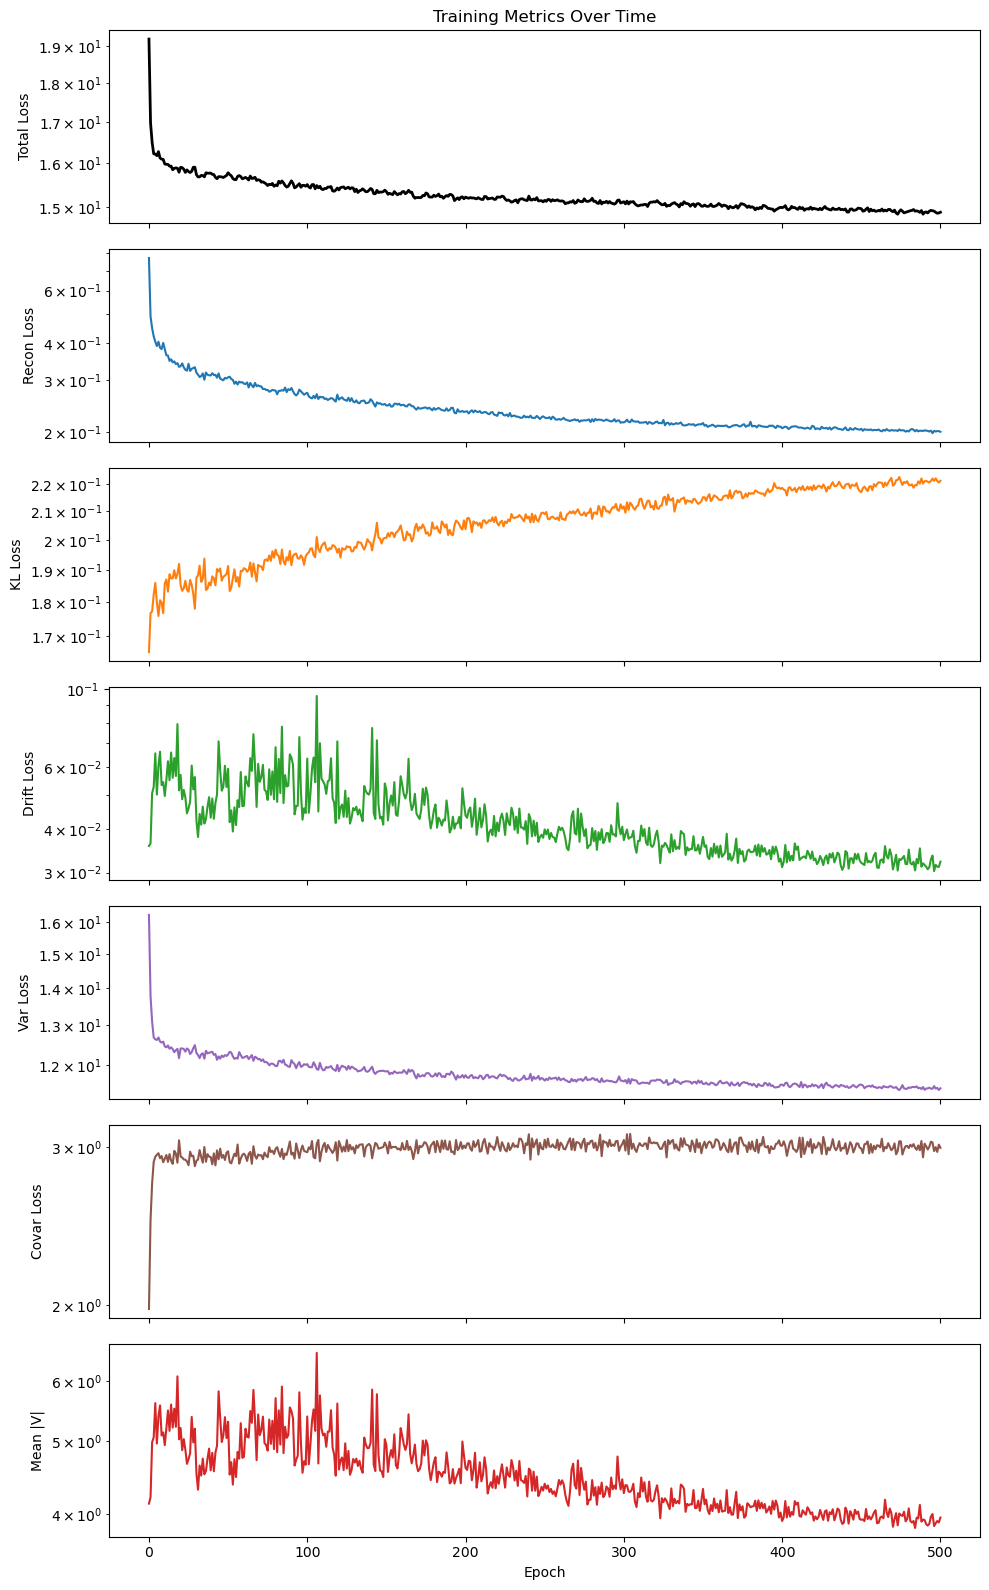

In [195]:
train_losses = to_float_list(train_losses)
recon_losses = to_float_list(recon_losses)
kl_losses = to_float_list(kl_losses)
drift_losses = to_float_list(drift_losses)
var_losses = to_float_list(var_losses)
covar_losses = to_float_list(covar_losses)
average_V = to_float_list(average_V)

# 3. Create 7 separate subplots stacked vertically
# We increase the figure height (e.g., 16) so they aren't squished
fig, axes = plt.subplots(7, 1, figsize=(10, 16), sharex=True)

# Total Loss
axes[0].plot(train_losses, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Metrics Over Time')

# Recon Loss
axes[1].plot(recon_losses, color='tab:blue')
axes[1].set_yscale('log')
axes[1].set_ylabel('Recon Loss')

# KL Loss
axes[2].plot(kl_losses, color='tab:orange')
axes[2].set_yscale('log')
axes[2].set_ylabel('KL Loss')

# Drift Loss
axes[3].plot(drift_losses, color='tab:green')
axes[3].set_yscale('log')
axes[3].set_ylabel('Drift Loss')

# Var Loss
axes[4].plot(var_losses, color='tab:purple')
axes[4].set_yscale('log')
axes[4].set_ylabel('Var Loss')

# Covar Loss
axes[5].plot(covar_losses, color='tab:brown')
axes[5].set_yscale('log')
axes[5].set_ylabel('Covar Loss')

# Average V (Drift Field Magnitude)
axes[6].plot(average_V, color='tab:red')
axes[6].set_yscale('log')
axes[6].set_ylabel('Mean |V|')
axes[6].set_xlabel('Epoch') # Only need x-label on the very bottom graph

plt.tight_layout()
plt.show()

In [183]:
def plot_direct_reconstructions(model, loader, num_images=5):
    """
    Plots real images directly next to their VAE reconstructions.
    Completely bypasses the noise sampling and drift generator.
    """
    model.eval() # Ensure dropout and batchnorm are in eval mode
    with torch.no_grad():
        # 1. Grab a single batch from your dataloader
        batch = next(iter(loader))
        if isinstance(batch, list) or isinstance(batch, tuple):
            real_images = batch[0]
        else:
            real_images = batch
            
        real_images = real_images[:num_images].to(device)
        
        # 2. Push directly through the VAE (Encoder -> Decoder)
        _, _, latent_z = model.get_latent(real_images)
        reconstructed_images = model.decode(latent_z)
        
        # 3. Un-normalize from [-1, 1] to [0, 1] and clamp
        real_images = ((real_images * 0.5) + 0.5).clamp(0, 1)
        reconstructed_images = ((reconstructed_images * 0.5) + 0.5).clamp(0, 1)
        
        # 4. Format for Matplotlib (Move to CPU, reshape C,H,W to H,W,C)
        real_np = real_images.cpu().permute(0, 2, 3, 1).numpy()
        recon_np = reconstructed_images.cpu().permute(0, 2, 3, 1).numpy()
        
        # 5. Plot the comparison grid
        fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2.5, 5))
        fig.suptitle("Direct VAE Reconstructions (Top: Real | Bottom: Recon)", fontsize=16)
        
        for i in range(num_images):
            # Top row: Real Images
            axes[0, i].imshow(real_np[i])
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title("Real", fontweight='bold')
            
            # Bottom row: Reconstructed Images
            axes[1, i].imshow(recon_np[i])
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title("Recon", fontweight='bold')
                
        plt.tight_layout()
        plt.show()

In [ ]:
plot_direct_reconstructions(model, dataloader, num_images=6)

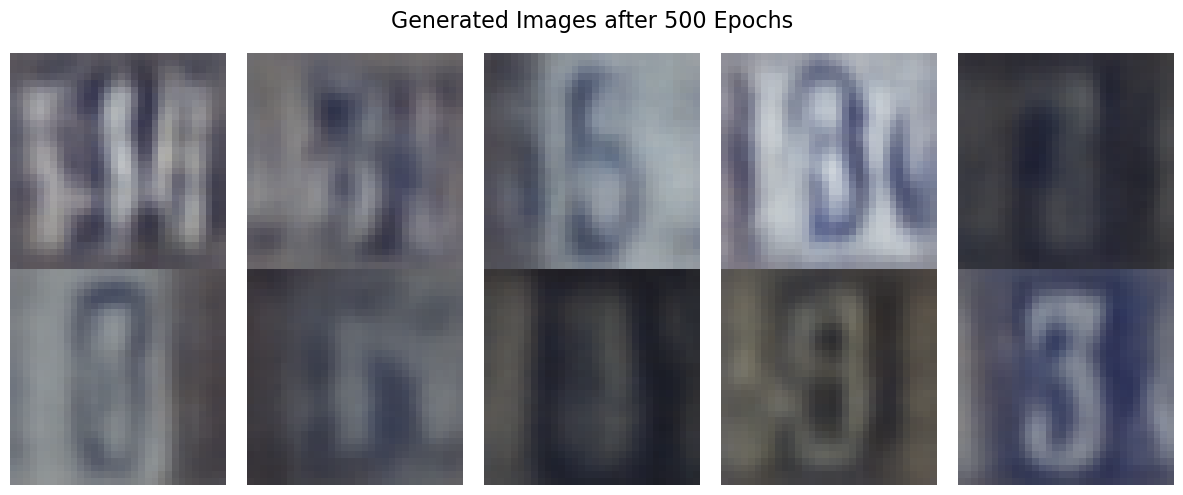

In [198]:
model.eval()
with torch.no_grad():
    # Sample random noise for 10 new images (Batch, Latent_Dim)
    sample_noise = torch.randn(10, model.latent_dim, device=device)
    
    # Generate the images purely from the noise
    _, generated_images = model.generate(sample_noise)
    
    # Un-normalize from [-1, 1] to [0, 1] and clamp
    generated_images = ((generated_images * 0.5) + 0.5).clamp(0, 1)
    
    # Move to CPU, reshape from (N, C, H, W) to (N, H, W, C) for Matplotlib
    generated_images = generated_images.cpu().permute(0, 2, 3, 1).numpy()

    # Plot the grid
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f"Generated Images after {num_epochs} Epochs", fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

approximate repulsion by resampling ever so often. 
initialize encoder close to pretrained encoder 
- i will train one my own and use that and maybe also used a pretrained one from someone else

multiobjective optimization
driftXpress + joint